# Intel Image Classification (4 Classes)
**Author:** Muhammad Akbar Pradana  
**Email:** akbarprdn2512@gmail.com  
**Dicoding ID:** akbarprdna  

Transfer learning with **EfficientNetB0** to classify natural scenes into 4 classes: `buildings`, `forest`, `mountain`, `sea`.

## 1. Import Libraries

In [1]:
# Standard & third-party imports
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU Available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.21.0
GPU Available      : []


## 2. Configuration & Paths

In [2]:
# ── Paths ───────────────────────────────────────────────────────────────────
BASE_DIR        = r'c:/Users/akbar/VSCode Project/intel-image-4class'
DATA_DIR        = os.path.join(BASE_DIR, 'data', 'intel-image-classification')
FIGURES_DIR     = os.path.join(BASE_DIR, 'figures')
MODELS_DIR      = os.path.join(BASE_DIR, 'models')
SAVED_MODEL_DIR = os.path.join(MODELS_DIR, 'saved_model')
TFLITE_DIR      = os.path.join(MODELS_DIR, 'tflite')
TFJS_DIR        = os.path.join(MODELS_DIR, 'tfjs_model')
CHECKPOINT_PATH = os.path.join(MODELS_DIR, 'best_model.keras')

# ── Hyper-parameters ────────────────────────────────────────────────────────
SELECTED_CLASSES = ['forest', 'sea', 'mountain', 'buildings']
IMG_SIZE         = (224, 224)
BATCH_SIZE       = 32
EPOCHS_FROZEN    = 10   # train only classifier head
EPOCHS_FINETUNE  = 15   # unfreeze top layers
SEED             = 42

# Create output directories
for d in [FIGURES_DIR, MODELS_DIR, SAVED_MODEL_DIR, TFLITE_DIR, TFJS_DIR]:
    os.makedirs(d, exist_ok=True)

print('All directories ready.')

All directories ready.


## 3. Data Preparation

### 3.1 Download Dataset from Kaggle

In [3]:
# Load Kaggle credentials from kaggle.json (never hard-code API keys in notebooks!)
kaggle_json_path = os.path.join(BASE_DIR, 'kaggle.json')
kaggle_cfg_dir   = os.path.expanduser('~/.kaggle')

os.makedirs(kaggle_cfg_dir, exist_ok=True)

# Copy credentials only if the file exists
if os.path.exists(kaggle_json_path):
    import shutil
    dest = os.path.join(kaggle_cfg_dir, 'kaggle.json')
    shutil.copy2(kaggle_json_path, dest)
    os.chmod(dest, 0o600)
    print('Kaggle credentials configured.')
else:
    print('WARNING: kaggle.json not found — skipping credential setup.')

# Download & unzip (skip if already present)
zip_flag = os.path.join(DATA_DIR, '..', 'intel-image-classification.zip')
if not os.path.isdir(DATA_DIR):
    os.makedirs(os.path.dirname(DATA_DIR), exist_ok=True)
    !kaggle datasets download -d puneet6060/intel-image-classification \\
        --unzip -p "{os.path.dirname(DATA_DIR)}"
    print('Dataset downloaded.')
else:
    print('Dataset already present — skipping download.')

Kaggle credentials configured.
Dataset already present — skipping download.


### 3.2 Build DataFrame

In [4]:
def build_dataframe(split_name: str, classes: list) -> pd.DataFrame:
    """Walk <split>/<split>/<class>/ and return a tidy DataFrame."""
    split_dir = os.path.join(DATA_DIR, split_name, split_name)
    rows = []
    for cls in os.listdir(split_dir):
        if cls not in classes:
            continue
        cls_dir = os.path.join(split_dir, cls)
        for img_name in os.listdir(cls_dir):
            rows.append({'path': os.path.join(cls_dir, img_name), 'label': cls})
    return pd.DataFrame(rows)

# Use only seg_train; split manually for train / val / test
all_df = build_dataframe('seg_train', SELECTED_CLASSES)
print(f'Total images : {len(all_df)}')
print(f'Classes      : {sorted(all_df["label"].unique())}')
print(f'\nClass distribution:\n{all_df["label"].value_counts()}')

Total images : 9248
Classes      : ['buildings', 'forest', 'mountain', 'sea']

Class distribution:
label
mountain     2512
sea          2274
forest       2271
buildings    2191
Name: count, dtype: int64


### 3.3 Visualize Class Distribution

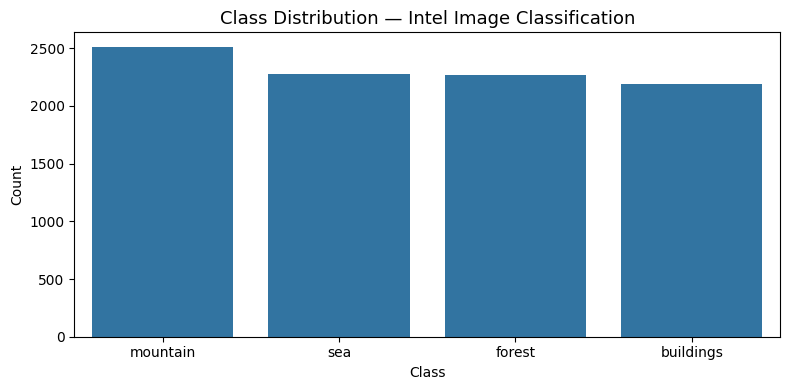

Figure saved.


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=all_df, x='label',
              order=all_df['label'].value_counts().index, ax=ax)
ax.set_title('Class Distribution — Intel Image Classification', fontsize=13)
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print('Figure saved.')

### 3.4 Sample Images per Class

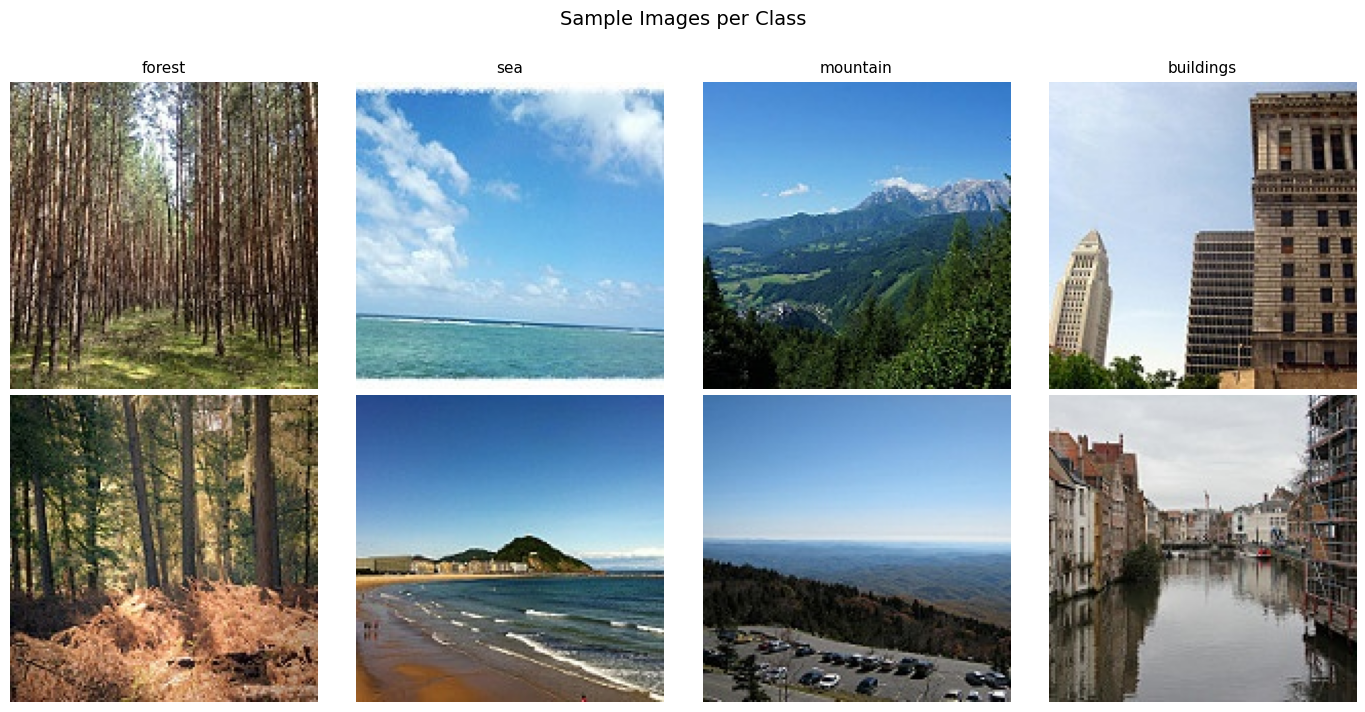

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, cls in enumerate(SELECTED_CLASSES):
    cls_paths = all_df[all_df['label'] == cls]['path'].sample(2, random_state=SEED).values
    for row, path in enumerate(cls_paths):
        ax = axes[row, col]
        ax.imshow(mpimg.imread(path))
        ax.set_title(cls if row == 0 else '', fontsize=11)
        ax.axis('off')
fig.suptitle('Sample Images per Class', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'sample_images.png'), dpi=150)
plt.show()

### 3.5 Train / Validation / Test Split

In [7]:
# 70 % train | 15 % val | 15 % test  (stratified)
train_df, temp_df = train_test_split(
    all_df, test_size=0.30, random_state=SEED, stratify=all_df['label'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])

print(f'Train  : {len(train_df):>5} images')
print(f'Val    : {len(val_df):>5} images')
print(f'Test   : {len(test_df):>5} images')

Train  :  6473 images
Val    :  1387 images
Test   :  1388 images


### 3.6 Data Generators

In [8]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
# Validation / test generators — preprocessing only
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

def make_gen(datagen, df, shuffle=True):
    return datagen.flow_from_dataframe(
        df, x_col='path', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=shuffle, seed=SEED
    )

train_gen = make_gen(train_datagen, train_df, shuffle=True)
val_gen   = make_gen(eval_datagen,  val_df,   shuffle=False)
test_gen  = make_gen(eval_datagen,  test_df,  shuffle=False)

class_names = list(train_gen.class_indices.keys())
print('Class indices:', train_gen.class_indices)

Found 6473 validated image filenames belonging to 4 classes.
Found 1387 validated image filenames belonging to 4 classes.
Found 1388 validated image filenames belonging to 4 classes.
Class indices: {'buildings': 0, 'forest': 1, 'mountain': 2, 'sea': 3}


## 4. Modelling

### 4.1 Build Model

In [9]:
def build_model(num_classes: int = 4) -> tf.keras.Model:
    """EfficientNetB0 backbone with a custom classification head."""
    backbone = EfficientNetB0(
        include_top=False, weights='imagenet',
        input_shape=(*IMG_SIZE, 3)
    )
    backbone.trainable = False  # freeze backbone initially

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='EfficientNetB0_4Class')

model = build_model(num_classes=len(class_names))
model.summary()

Model: "EfficientNetB0_4Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

### 4.2 Callbacks

In [10]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy',
                     save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                       patience=3, min_lr=1e-6, verbose=1)
]

### 4.3 Phase 1 — Train Classifier Head (backbone frozen)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_frozen = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.9116 - loss: 0.2793
Epoch 1: val_accuracy improved from None to 0.99063, saving model to c:/Users/akbar/VSCode Project/intel-image-4class\models\best_model.keras

Epoch 1: finished saving model to c:/Users/akbar/VSCode Project/intel-image-4class\models\best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 154s 718ms/step - accuracy: 0.9481 - loss: 0.1867 - val_accuracy: 0.9906 - val_loss: 0.0375 - learning_rate: 0.0010
Epoch 2/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.9704 - loss: 0.0994
Epoch 2: val_accuracy did not improve from 0.99063
203/203 ━━━━━━━━━━━━━━━━━━━━ 138s 682ms/step - accuracy: 0.9686 - loss: 0.1051 - val_accuracy: 0.9906 - val_loss: 0.0270 - learning_rate: 0.0010
Epoch 3/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9723 - loss: 0.0880
Epoch 3: val_accuracy improved from 0.99063 to 0.99207, saving model to c:/Users/akbar/VSCode Project/intel-image-4class\models\best_model.keras


### 4.4 Phase 2 — Fine-tune Top Layers

In [12]:
# Unfreeze the last 30 layers of the backbone
model.layers[1].trainable = True  # backbone is layer index 1
for layer in model.layers[1].layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9266 - loss: 0.2429
Epoch 1: val_accuracy did not improve from 0.99279
203/203 ━━━━━━━━━━━━━━━━━━━━ 163s 758ms/step - accuracy: 0.9345 - loss: 0.2099 - val_accuracy: 0.9813 - val_loss: 0.0722 - learning_rate: 1.0000e-05
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9495 - loss: 0.1490
Epoch 2: val_accuracy did not improve from 0.99279
203/203 ━━━━━━━━━━━━━━━━━━━━ 152s 750ms/step - accuracy: 0.9509 - loss: 0.1485 - val_accuracy: 0.9776 - val_loss: 0.0758 - learning_rate: 1.0000e-05
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9511 - loss: 0.1264
Epoch 3: val_accuracy did not improve from 0.99279

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
203/203 ━━━━━━━━━━━━━━━━━━━━ 152s 749ms/step - accuracy: 0.9560 - loss: 0.1183 - val_accuracy: 0.9805 - val_loss: 0.0680 - learning_rate: 1.0000e-05
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - acc

## 5. Evaluation & Visualisation

### 5.1 Training Curves

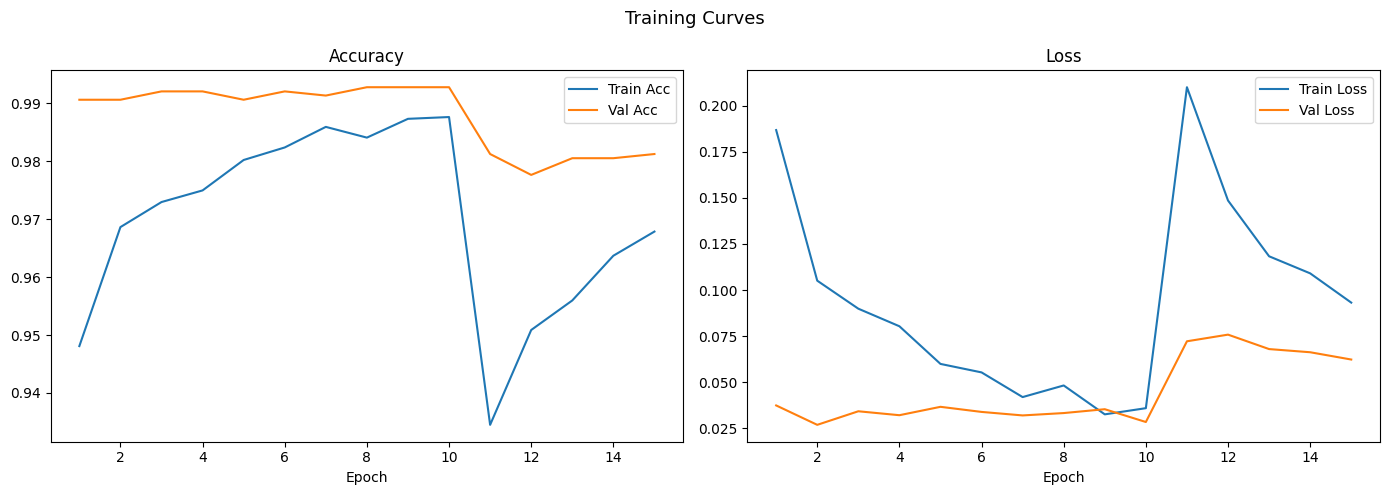

In [13]:
def plot_history(h_frozen, h_ft):
    """Combine frozen + fine-tune histories and plot accuracy/loss curves."""
    acc  = h_frozen.history['accuracy']      + h_ft.history['accuracy']
    val_acc = h_frozen.history['val_accuracy'] + h_ft.history['val_accuracy']
    loss = h_frozen.history['loss']           + h_ft.history['loss']
    val_loss = h_frozen.history['val_loss']   + h_ft.history['val_loss']
    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, acc,     label='Train Acc')
    ax1.plot(epochs, val_acc, label='Val Acc')
    ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

    ax2.plot(epochs, loss,     label='Train Loss')
    ax2.plot(epochs, val_loss, label='Val Loss')
    ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

    plt.suptitle('Training Curves', fontsize=13)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'training_curves.png'), dpi=150)
    plt.show()

plot_history(history_frozen, history_ft)

### 5.2 Classification Report & Confusion Matrix

44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 480ms/step
              precision    recall  f1-score   support

   buildings       0.97      1.00      0.98       329
      forest       0.99      0.98      0.98       341
    mountain       0.97      0.96      0.97       377
         sea       0.97      0.96      0.97       341

    accuracy                           0.97      1388
   macro avg       0.97      0.98      0.97      1388
weighted avg       0.97      0.97      0.97      1388



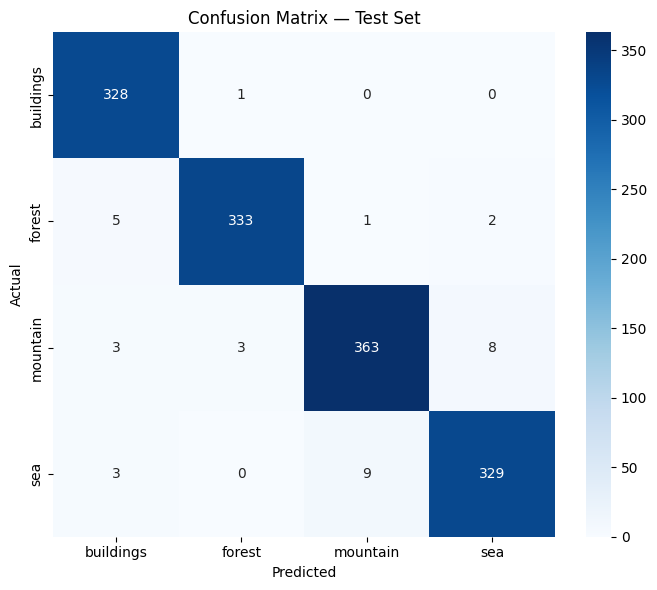

In [14]:
test_gen.reset()
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen.classes

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix — Test Set')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 6. Model Conversion & Export

### 6.1 SavedModel

In [15]:
model.export(SAVED_MODEL_DIR)
print(f'SavedModel saved to: {SAVED_MODEL_DIR}')

INFO:tensorflow:Assets written to: c:/Users/akbar/VSCode Project/intel-image-4class\models\saved_model\assets


INFO:tensorflow:Assets written to: c:/Users/akbar/VSCode Project/intel-image-4class\models\saved_model\assets


Saved artifact at 'c:/Users/akbar/VSCode Project/intel-image-4class\models\saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2971725103568: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2971725107984: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2971702301456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2971702302224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2971702302992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2971702299920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2971702301264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2971702303760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2971702305488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2971702305680: TensorSpec(sha

### 6.2 TF-Lite (dynamic-range quantisation)

In [16]:
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = os.path.join(TFLITE_DIR, 'model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# Save class labels alongside the TFLite model
with open(os.path.join(TFLITE_DIR, 'label.txt'), 'w') as f:
    f.write('\n'.join(class_names))

print(f'TFLite model saved ({len(tflite_model)/1024/1024:.2f} MB) -> {tflite_path}')
print(f'Labels: {class_names}')

TFLite model saved (4.68 MB) -> c:/Users/akbar/VSCode Project/intel-image-4class\models\tflite\model.tflite
Labels: ['buildings', 'forest', 'mountain', 'sea']


### 6.3 TensorFlow.js

In [ ]:
import sys

try:
    from tensorflowjs.converters.converter import convert
    
    sys.argv = [
        'tensorflowjs_converter',
        '--input_format=tf_saved_model',
        '--output_format=tfjs_graph_model',
        SAVED_MODEL_DIR,
        TFJS_DIR
    ]
    convert(sys.argv[1:])
    print(f'TFJS model saved to: {TFJS_DIR}')

except ImportError:
    print("tensorflowjs tidak terdeteksi di sistem Anda.")
    print("Mengeksekusi konversi ke TFJS dilewati (Skipped).")
    print("Catatan: tensorflowjs saat ini belum mendukung Python 3.12 di Windows secara native.")


ModuleNotFoundError: No module named 'tensorflowjs'

## 7. Reload Model (Kernel-Restart Safe)

In [ ]:
# Run this cell to restore model & class names after a kernel restart
# without re-training from scratch.

if os.path.exists(CHECKPOINT_PATH):
    model = keras.models.load_model(CHECKPOINT_PATH)
    print(f'Model loaded from checkpoint: {CHECKPOINT_PATH}')
elif os.path.isdir(SAVED_MODEL_DIR):
    model = keras.models.load_model(SAVED_MODEL_DIR)
    print(f'Model loaded from SavedModel: {SAVED_MODEL_DIR}')
else:
    print('No saved model found — please run training cells first.')

# Restore class names from label.txt
label_path = os.path.join(TFLITE_DIR, 'label.txt')
if os.path.exists(label_path):
    with open(label_path) as f:
        class_names = f.read().splitlines()
    print(f'Class names restored: {class_names}')

## 8. Inference Demo

In [ ]:
import random
from PIL import Image

def predict_single(img_path: str) -> dict:
    """Run inference on a single image and return class probabilities."""
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    arr = np.expand_dims(np.array(img, dtype='float32'), 0)
    arr = preprocess_input(arr)
    probs = model.predict(arr, verbose=0)[0]
    return {cls: float(p) for cls, p in zip(class_names, probs)}

# Pick one random test image per class
fig, axes = plt.subplots(1, len(class_names), figsize=(14, 4))
for ax, cls in zip(axes, class_names):
    sample_path = test_df[test_df['label'] == cls]['path'].sample(1, random_state=SEED).values[0]
    preds = predict_single(sample_path)
    top_cls = max(preds, key=preds.get)
    color = 'green' if top_cls == cls else 'red'
    ax.imshow(mpimg.imread(sample_path))
    ax.set_title(f'True: {cls}\nPred: {top_cls} ({preds[top_cls]:.0%})',
                 color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Inference Demo', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'inference_demo.png'), dpi=150)
plt.show()